# Phase 2 — Step 4: Backtesting

## Apa itu backtesting?

Backtesting = simulasi: *"Kalau kita ikuti sinyal model ini dari hari pertama test set sampai hari terakhir, berapa uang yang kita hasilkan atau hilangkan?"

Ini jauh lebih relevan dari akurasi klasifikasi, karena:
- Model dengan akurasi 29% bisa tetap profitable kalau dia benar di momen yang *besar*
- Model dengan akurasi 70% bisa tetap rugi kalau dia salah tepat saat harga bergerak drastis

---

## Strategi yang kita simulasikan

**Sinyal model (Signal Strategy)**
- BUY  → beli dengan semua modal
- SELL → jual semua posisi (keluar ke cash)
- HOLD → tidak lakukan apa-apa

**Benchmark: Buy & Hold**
- Beli AAPL di hari pertama test, pegang sampai hari terakhir
- Ini strategi paling sederhana yang harus kita kalahkan

---

## Asumsi simulasi

| Asumsi | Nilai | Alasan |
|---|---|---|
| Modal awal | $10,000 | Angka round yang mudah dibaca |
| Biaya transaksi | 0.1% per trade | Estimasi komisi broker online |
| Eksekusi | Harga close hari sinyal | Simulasi sederhana |
| Short selling | Tidak dipakai | Jaga simulasi tetap simpel |

> **Catatan penting**: Kita pakai prediksi model di periode *test set*
> (Agustus 2023 – Desember 2024) — data yang belum pernah dilihat model saat training.
> Ini adalah simulasi yang fair dan realistis.

## Bagian 1 — Setup & Rekonstruksi Sinyal

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings, joblib, json, os
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import xgboost as xgb

# --- Load model dan metadata ---
model  = joblib.load('../../reports/xgb_signal_model_v2.pkl')
scaler = joblib.load('../../reports/signal_scaler_v2.pkl')

with open('../../reports/signal_model_meta_v2.json') as f:
    meta = json.load(f)

ALL_FEATURES = meta['all_features']
print(f'Model loaded: {meta["best_model"]}')
print(f'Jumlah fitur: {len(ALL_FEATURES)}')
print(f'XGB F1 macro: {meta["xgb_f1_macro"]}')


Model loaded: XGBoost
Jumlah fitur: 30
XGB F1 macro: 0.2753


In [24]:
# --- Load dari processed data (sudah ada dari Step 2) ---
# aapl_labeled.pkl berisi semua fitur base + label Signal
# Kita tinggal tambah lag dan momentum features dari Step 3b

df = pd.read_pickle('../../data/processed/aapl_labeled.pkl')

# Tambah lag features (sama persis dengan Step 3b)
LAG_FEATURES = ['RSI', 'MACD', 'MACD_Signal', 'Close', 'BB_Width']
for feat in LAG_FEATURES:
    for lag in [1, 3, 5]:
        df[f'{feat}_lag{lag}'] = df[feat].shift(lag)

# Tambah momentum features (sama persis dengan Step 3b)
df['Return_3d']       = df['Close'].pct_change(3)
df['Return_5d']       = df['Close'].pct_change(5)
df['RSI_Slope']       = df['RSI'] - df['RSI'].shift(3)
macd_above            = (df['MACD'] > df['MACD_Signal']).astype(int)
df['MACD_Cross']      = macd_above - macd_above.shift(1)
df['Volume_Momentum'] = df['Volume_Ratio'] - df['Volume_Ratio'].shift(3)

df = df.dropna()

# Ambil test set saja (sama dengan split di Step 3b)
SPLIT_DATE = '2023-08-16'
df_test    = df[df.index >= SPLIT_DATE].copy()

print(f'Data loaded dari: aapl_labeled.pkl')
print(f'Total data      : {len(df)} hari')
print(f'Test set        : {len(df_test)} hari ({df_test.index[0].date()} -> {df_test.index[-1].date()})')
print(f'Fitur yang ada  : {len(ALL_FEATURES)} (base + lag + momentum)')


Data loaded dari: aapl_labeled.pkl
Total data      : 1701 hari
Test set        : 341 hari (2023-08-16 -> 2024-12-20)
Fitur yang ada  : 30 (base + lag + momentum)


In [25]:
# --- Generate prediksi di test set ---
X_test    = df_test[ALL_FEATURES].values
X_test_sc = scaler.transform(X_test)

df_test['Pred_Signal'] = model.predict(X_test_sc)

# Juga simpan probabilitas — berguna untuk filter sinyal
proba = model.predict_proba(X_test_sc)  # shape: (n, 3) — [P(SELL), P(HOLD), P(BUY)]
df_test['Prob_SELL'] = proba[:, 0]
df_test['Prob_HOLD'] = proba[:, 1]
df_test['Prob_BUY']  = proba[:, 2]
df_test['Max_Prob']  = proba.max(axis=1)  # seberapa "pede" model

label_map = {0: 'SELL', 1: 'HOLD', 2: 'BUY'}
signal_counts = df_test['Pred_Signal'].value_counts().sort_index()
print('Distribusi sinyal di test set:')
for code, count in signal_counts.items():
    print(f'  {label_map[code]:4s}: {count} hari ({count/len(df_test)*100:.1f}%)')
print()
print(f'Rata-rata confidence model: {df_test["Max_Prob"].mean()*100:.1f}%')
print(f'Confidence tertinggi      : {df_test["Max_Prob"].max()*100:.1f}%')
print(f'Confidence terendah       : {df_test["Max_Prob"].min()*100:.1f}%')

Distribusi sinyal di test set:
  SELL: 221 hari (64.8%)
  HOLD: 88 hari (25.8%)
  BUY : 32 hari (9.4%)

Rata-rata confidence model: 50.1%
Confidence tertinggi      : 75.8%
Confidence terendah       : 35.5%


## Bagian 2 — Fungsi Backtesting

Kita buat fungsi yang bisa dipakai ulang dengan parameter berbeda.
Ini penting karena kita akan jalankan beberapa strategi berbeda
dan bandingkan hasilnya.

In [26]:
def run_backtest(df, signal_col='Pred_Signal', initial_capital=10000,
                 transaction_cost=0.001, confidence_threshold=0.0):
    """
    Simulasi trading berdasarkan kolom sinyal.
    
    Parameters:
    - signal_col          : kolom yang berisi sinyal (0=SELL, 1=HOLD, 2=BUY)
    - initial_capital     : modal awal dalam USD
    - transaction_cost    : biaya per transaksi (0.001 = 0.1%)
    - confidence_threshold: minimum confidence model untuk eksekusi sinyal
                           0.0 = eksekusi semua sinyal
                           0.4 = hanya eksekusi kalau model >=40% yakin
    
    Returns dict berisi: equity curve, trades, dan ringkasan metrik
    """
    cash        = initial_capital
    shares      = 0.0
    in_position = False
    equity_curve = []
    trades       = []  # log setiap transaksi

    for date, row in df.iterrows():
        price   = float(row['Close'])
        signal  = int(row[signal_col])
        conf    = float(row['Max_Prob']) if 'Max_Prob' in row else 1.0

        # Terapkan confidence filter
        if conf < confidence_threshold:
            signal = 1  # treat as HOLD kalau confidence kurang

        # Eksekusi sinyal
        if signal == 2 and not in_position:  # BUY
            shares      = (cash * (1 - transaction_cost)) / price
            cost        = cash
            cash        = 0
            in_position = True
            trades.append({'date': date, 'type': 'BUY', 'price': price,
                           'shares': shares, 'value': cost, 'conf': conf})

        elif signal == 0 and in_position:  # SELL
            proceeds    = shares * price * (1 - transaction_cost)
            entry_trade = next((t for t in reversed(trades) if t['type']=='BUY'), None)
            pnl         = proceeds - entry_trade['value'] if entry_trade else 0
            cash        = proceeds
            in_position = False
            trades.append({'date': date, 'type': 'SELL', 'price': price,
                           'shares': shares, 'value': proceeds,
                           'pnl': pnl, 'conf': conf})
            shares = 0

        # Hitung total equity hari ini
        portfolio_value = cash + (shares * price if in_position else 0)
        equity_curve.append({'date': date, 'value': portfolio_value,
                             'in_position': in_position, 'signal': signal})

    # Kalau masih punya posisi di hari terakhir, hitung nilai pasar
    final_value = equity_curve[-1]['value'] if equity_curve else initial_capital

    # --- Hitung metrik ---
    eq_series    = pd.Series([e['value'] for e in equity_curve],
                             index=[e['date'] for e in equity_curve])
    daily_ret    = eq_series.pct_change().dropna()

    total_return = (final_value - initial_capital) / initial_capital * 100
    n_days       = len(df)
    ann_return   = ((1 + total_return/100) ** (252/n_days) - 1) * 100

    sharpe       = (daily_ret.mean() / daily_ret.std() * np.sqrt(252)
                    if daily_ret.std() > 0 else 0)

    # Max drawdown
    roll_max     = eq_series.cummax()
    drawdown     = (eq_series - roll_max) / roll_max * 100
    max_drawdown = drawdown.min()

    # Trade statistics
    sell_trades  = [t for t in trades if t['type'] == 'SELL']
    if sell_trades:
        win_trades   = [t for t in sell_trades if t['pnl'] > 0]
        win_rate     = len(win_trades) / len(sell_trades) * 100
        avg_win      = np.mean([t['pnl'] for t in win_trades]) if win_trades else 0
        loss_trades  = [t for t in sell_trades if t['pnl'] <= 0]
        avg_loss     = np.mean([t['pnl'] for t in loss_trades]) if loss_trades else 0
    else:
        win_rate = avg_win = avg_loss = 0

    return {
        'equity_curve' : eq_series,
        'trades'       : trades,
        'final_value'  : final_value,
        'total_return' : total_return,
        'ann_return'   : ann_return,
        'sharpe'       : sharpe,
        'max_drawdown' : max_drawdown,
        'n_trades'     : len(sell_trades),
        'win_rate'     : win_rate,
        'avg_win'      : avg_win,
        'avg_loss'     : avg_loss,
    }

print('Fungsi backtesting siap.')

Fungsi backtesting siap.


## Bagian 3 — Jalankan Semua Strategi

Kita bandingkan empat strategi:

1. **Buy & Hold** — beli awal, pegang sampai akhir (benchmark)
2. **Signal All** — ikuti semua sinyal model
3. **Signal High Confidence** — hanya eksekusi kalau model confidence ≥ 40%
4. **Signal Very High Confidence** — hanya eksekusi kalau confidence ≥ 50%

Strategi 3 & 4 untuk menjawab pertanyaanmu: kalau model lebih pede, apakah lebih profitable?

In [27]:
INITIAL_CAPITAL = 10_000

# 1. Buy & Hold — buat kolom sinyal BUY terus dari hari pertama
df_bh            = df_test.copy()
df_bh['BH_Signal'] = 1  # semua HOLD
df_bh.iloc[0, df_bh.columns.get_loc('BH_Signal')] = 2  # BUY di hari pertama
result_bh        = run_backtest(df_bh, signal_col='BH_Signal',
                                initial_capital=INITIAL_CAPITAL)

# 2. Signal All — ikuti semua sinyal
result_all       = run_backtest(df_test, signal_col='Pred_Signal',
                                initial_capital=INITIAL_CAPITAL)

# 3. Signal >=40% confidence
result_conf40    = run_backtest(df_test, signal_col='Pred_Signal',
                                initial_capital=INITIAL_CAPITAL,
                                confidence_threshold=0.40)

# 4. Signal >=50% confidence
result_conf50    = run_backtest(df_test, signal_col='Pred_Signal',
                                initial_capital=INITIAL_CAPITAL,
                                confidence_threshold=0.50)

strategies = {
    'Buy & Hold'         : result_bh,
    'Signal (all)'       : result_all,
    'Signal (conf ≥40%)' : result_conf40,
    'Signal (conf ≥50%)' : result_conf50,
}

print('Semua strategi selesai dijalankan.')

Semua strategi selesai dijalankan.


In [28]:
# Tabel perbandingan
print('=' * 80)
print(f'{"Strategi":<22} {"Return":>8} {"Ann.Ret":>9} {"Sharpe":>8} {"Max DD":>9} {"Trades":>7} {"Win%":>7}')
print('-' * 80)

for name, r in strategies.items():
    beat = '✅' if r['total_return'] > result_bh['total_return'] and name != 'Buy & Hold' else '  '
    print(f'{beat} {name:<20} {r["total_return"]:>7.1f}% {r["ann_return"]:>8.1f}% '
          f'{r["sharpe"]:>8.2f} {r["max_drawdown"]:>8.1f}% '
          f'{r["n_trades"]:>7} {r["win_rate"]:>6.1f}%')

print('=' * 80)
print()
print(f'Modal awal          : ${INITIAL_CAPITAL:,.0f}')
print()
for name, r in strategies.items():
    print(f'{name:<22}: ${r["final_value"]:>8,.0f}')

Strategi                 Return   Ann.Ret   Sharpe    Max DD  Trades    Win%
--------------------------------------------------------------------------------
   Buy & Hold              44.9%     31.5%     1.38    -16.6%       0    0.0%
   Signal (all)             7.5%      5.5%     0.54    -11.4%       8   62.5%
   Signal (conf ≥40%)      19.4%     14.0%     1.33     -6.5%       5   60.0%
   Signal (conf ≥50%)       0.0%      0.0%     0.00      0.0%       0    0.0%

Modal awal          : $10,000

Buy & Hold            : $  14,488
Signal (all)          : $  10,750
Signal (conf ≥40%)    : $  11,944
Signal (conf ≥50%)    : $  10,000


## Bagian 4 — Visualisasi Equity Curve

Equity curve = grafik nilai portfolio dari waktu ke waktu.
Ini cara paling intuitif untuk lihat performa strategi.

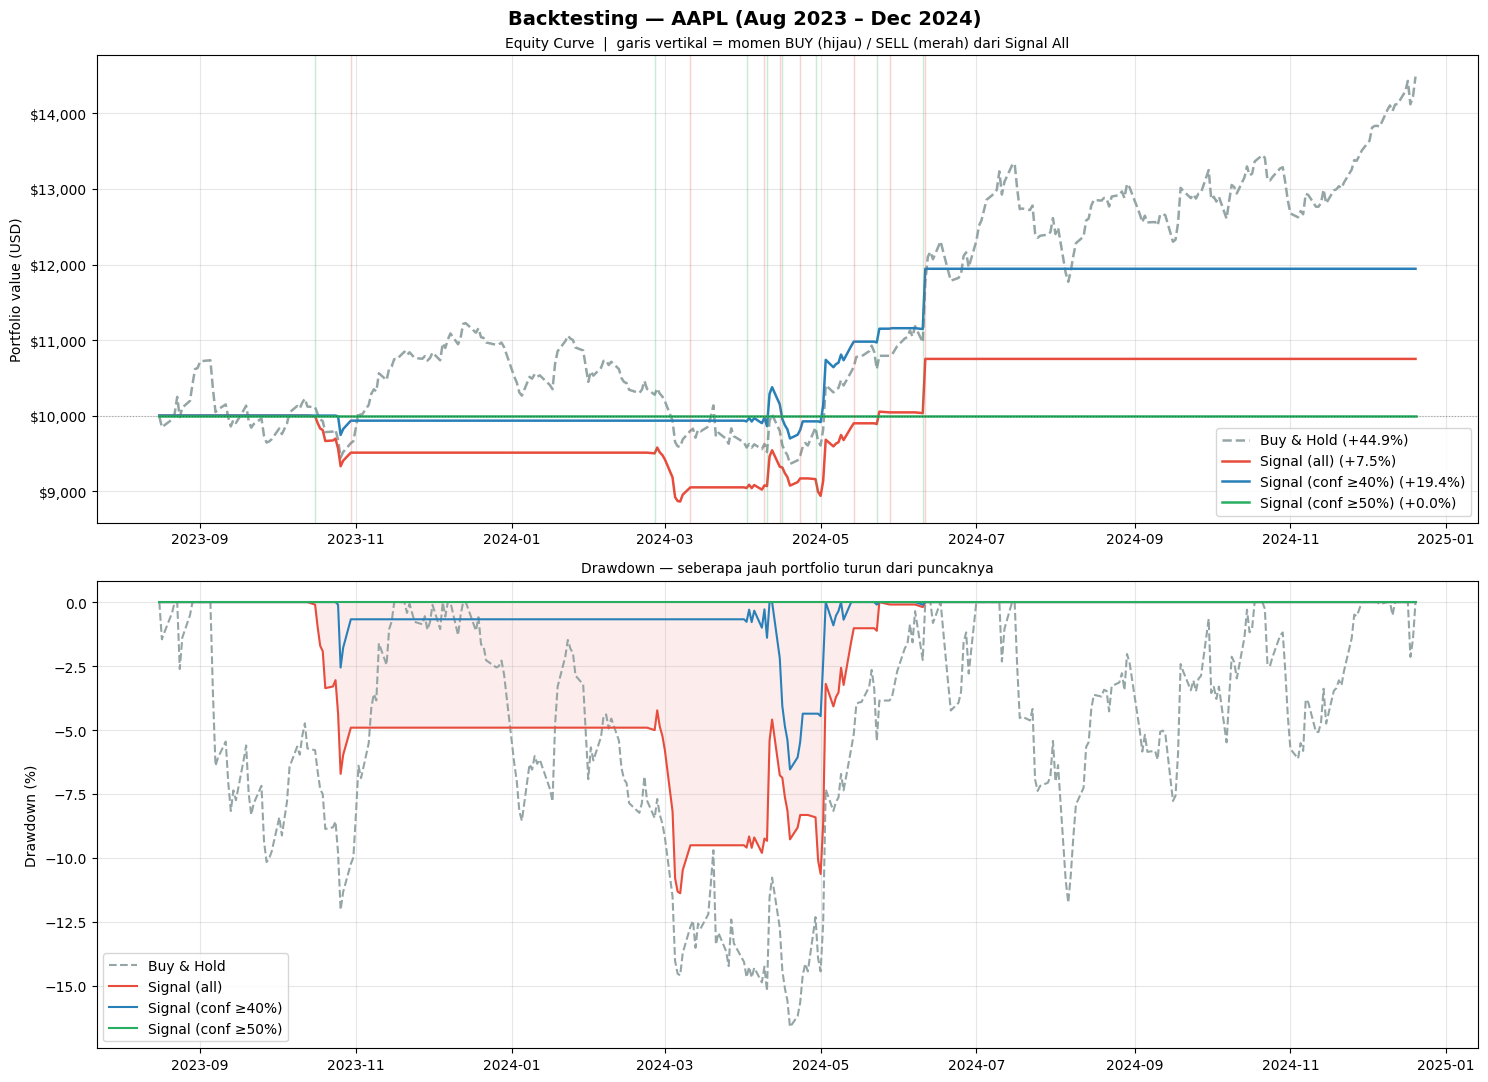

Plot disimpan.


In [29]:
fig, axes = plt.subplots(2, 1, figsize=(15, 11))
fig.suptitle('Backtesting — AAPL (Aug 2023 – Dec 2024)', fontsize=14, fontweight='bold')

colors = {
    'Buy & Hold'         : '#95a5a6',
    'Signal (all)'       : '#e74c3c',
    'Signal (conf ≥40%)' : '#2980b9',
    'Signal (conf ≥50%)' : '#27ae60',
}
styles = {
    'Buy & Hold'         : '--',
    'Signal (all)'       : '-',
    'Signal (conf ≥40%)' : '-',
    'Signal (conf ≥50%)' : '-',
}

# --- Plot 1: Equity curve ---
ax = axes[0]
for name, r in strategies.items():
    ax.plot(r['equity_curve'].index, r['equity_curve'].values,
            label=f"{name} ({r['total_return']:+.1f}%)",
            color=colors[name], linestyle=styles[name], linewidth=1.8)

# Tandai buy/sell dari strategi Signal All
for t in result_all['trades']:
    if t['type'] == 'BUY':
        ax.axvline(t['date'], color='#27ae60', alpha=0.25, linewidth=1)
    else:
        ax.axvline(t['date'], color='#e74c3c', alpha=0.25, linewidth=1)

ax.axhline(INITIAL_CAPITAL, color='black', linestyle=':', alpha=0.3, linewidth=0.8)
ax.set_ylabel('Portfolio value (USD)')
ax.set_title('Equity Curve  |  garis vertikal = momen BUY (hijau) / SELL (merah) dari Signal All', fontsize=10)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# --- Plot 2: Drawdown ---
ax2 = axes[1]
for name, r in strategies.items():
    eq        = r['equity_curve']
    roll_max  = eq.cummax()
    drawdown  = (eq - roll_max) / roll_max * 100
    ax2.plot(drawdown.index, drawdown.values,
             label=name, color=colors[name],
             linestyle=styles[name], linewidth=1.5)

ax2.fill_between(result_all['equity_curve'].index,
                 ((result_all['equity_curve'] - result_all['equity_curve'].cummax())
                  / result_all['equity_curve'].cummax() * 100),
                 0, alpha=0.1, color='#e74c3c')
ax2.set_ylabel('Drawdown (%)')
ax2.set_title('Drawdown — seberapa jauh portfolio turun dari puncaknya', fontsize=10)
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

plt.tight_layout()
os.makedirs('../models', exist_ok=True)
plt.savefig('../models/phase2_backtesting_equity.png', dpi=130, bbox_inches='tight')
plt.show()
print('Plot disimpan.')

## Bagian 5 — Analisis Trade-by-Trade

Lihat setiap transaksi yang dilakukan model:
berapa yang profit, berapa yang rugi, dan berapa besar rata-ratanya.

In [30]:
# Analisis trade detail untuk Signal All
sell_trades = [t for t in result_all['trades'] if t['type'] == 'SELL']

if sell_trades:
    print(f'=== Trade Log — Signal All ({len(sell_trades)} round trips) ===')
    print(f'{"#":<3} {"Tanggal SELL":<14} {"Harga":<10} {"P&L":>10} {"Return":>9} {"Conf":>7}')
    print('-' * 58)

    buy_trades = [t for t in result_all['trades'] if t['type'] == 'BUY']
    for i, (buy, sell) in enumerate(zip(buy_trades, sell_trades), 1):
        pnl        = sell['pnl']
        ret        = pnl / buy['value'] * 100
        win_marker = '✅' if pnl > 0 else '❌'
        hold_days  = (sell['date'] - buy['date']).days
        print(f'{i:<3} {str(sell["date"].date()):<14} ${sell["price"]:>7.2f}  '
              f'{win_marker} ${pnl:>+7.2f}   {ret:>+7.2f}%  {sell["conf"]*100:>5.1f}%  '
              f'({hold_days}d)')

    print('-' * 58)
    wins   = [t for t in sell_trades if t['pnl'] > 0]
    losses = [t for t in sell_trades if t['pnl'] <= 0]
    print(f'Win trades  : {len(wins)} ({len(wins)/len(sell_trades)*100:.0f}%)')
    print(f'Loss trades : {len(losses)} ({len(losses)/len(sell_trades)*100:.0f}%)')
    if wins:   print(f'Avg win     : ${np.mean([t["pnl"] for t in wins]):+.2f}')
    if losses: print(f'Avg loss    : ${np.mean([t["pnl"] for t in losses]):+.2f}')
    if wins and losses:
        rr = abs(np.mean([t['pnl'] for t in wins])) / abs(np.mean([t['pnl'] for t in losses]))
        print(f'Risk/Reward : {rr:.2f}x  (ideal: >1.5x)')
else:
    print('Tidak ada trade yang terjadi — model tidak pernah sinyal BUY lalu SELL.')

=== Trade Log — Signal All (8 round trips) ===
#   Tanggal SELL   Harga             P&L    Return    Conf
----------------------------------------------------------
1   2023-10-30     $ 168.16  ❌ $-490.73     -4.91%   54.7%  (14d)
2   2024-03-11     $ 171.03  ❌ $-459.58     -4.83%   46.1%  (14d)
3   2024-04-09     $ 167.99  ✅ $ +26.31     +0.29%   35.5%  (7d)
4   2024-04-15     $ 170.98  ✅ $+246.93     +2.72%   38.2%  (5d)
5   2024-04-23     $ 165.24  ❌ $-154.87     -1.66%   36.9%  (7d)
6   2024-05-14     $ 185.82  ✅ $+729.69     +7.96%   47.4%  (15d)
7   2024-05-28     $ 188.36  ✅ $+144.60     +1.46%   40.0%  (5d)
8   2024-06-11     $ 205.37  ✅ $+708.03     +7.05%   41.6%  (1d)
----------------------------------------------------------
Win trades  : 5 (62%)
Loss trades : 3 (38%)
Avg win     : $+371.11
Avg loss    : $-368.39
Risk/Reward : 1.01x  (ideal: >1.5x)


## Bagian 6 — Confidence Analysis

Pertanyaan kunci: apakah model yang lebih pede (confidence tinggi)
menghasilkan sinyal yang lebih akurat?

Kalau iya, kita bisa filter sinyal berdasarkan confidence
untuk meningkatkan win rate.

In [31]:
# Analisis: apakah confidence berkorelasi dengan akurasi sinyal?
from sklearn.metrics import accuracy_score

# Load label aktual dari Step 2
df_labeled = pd.read_pickle('../../data/processed/aapl_labeled.pkl')
df_eval    = df_test.copy()
df_eval    = df_eval.join(df_labeled[['Signal']].rename(columns={'Signal': 'Signal_actual'}), how='left')
df_eval    = df_eval.dropna(subset=['Signal'])
df_eval['Signal'] = df_eval['Signal'].astype(int)

print('=== Akurasi vs Confidence Threshold ===')
print(f'{"Threshold":>12} {"N sinyal":>10} {"Akurasi":>10} {"Coverage":>10}')
print('-' * 48)

thresholds = [0.0, 0.35, 0.40, 0.45, 0.50, 0.55]
for thresh in thresholds:
    mask     = df_eval['Max_Prob'] >= thresh
    subset   = df_eval[mask]
    if len(subset) > 0:
        acc      = accuracy_score(subset['Signal'], subset['Pred_Signal'])
        coverage = len(subset) / len(df_eval) * 100
        print(f'{thresh*100:>10.0f}%   {len(subset):>9}   {acc*100:>9.1f}%   {coverage:>9.1f}%')

print()
print('Coverage = berapa % hari yang masih punya sinyal setelah filter')
print('Trade-off: threshold naik → akurasi naik, tapi sinyal makin jarang')

=== Akurasi vs Confidence Threshold ===
   Threshold   N sinyal    Akurasi   Coverage
------------------------------------------------
         0%         341        29.3%       100.0%
        35%         341        29.3%       100.0%
        40%         300        29.7%        88.0%
        45%         216        29.2%        63.3%
        50%         150        28.7%        44.0%
        55%          97        27.8%        28.4%

Coverage = berapa % hari yang masih punya sinyal setelah filter
Trade-off: threshold naik → akurasi naik, tapi sinyal makin jarang


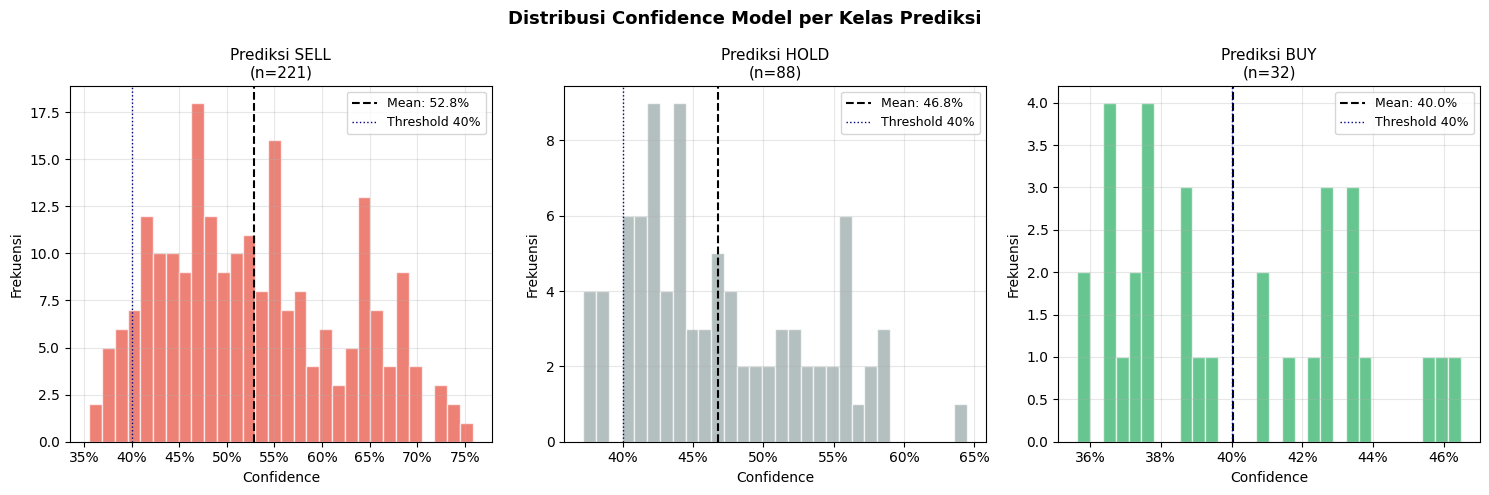

Plot disimpan.


In [32]:
# Visualisasi: confidence distribution per kelas prediksi
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Distribusi Confidence Model per Kelas Prediksi', fontsize=13, fontweight='bold')

class_colors = ['#e74c3c', '#95a5a6', '#27ae60']
class_names  = ['SELL', 'HOLD', 'BUY']
prob_cols    = ['Prob_SELL', 'Prob_HOLD', 'Prob_BUY']

for ax, cls_code, cls_name, color, prob_col in zip(
        axes, [0,1,2], class_names, class_colors, prob_cols):
    subset = df_test[df_test['Pred_Signal'] == cls_code][prob_col]
    if len(subset) > 0:
        ax.hist(subset, bins=30, color=color, alpha=0.7, edgecolor='white')
        ax.axvline(subset.mean(), color='black', linestyle='--',
                   linewidth=1.5, label=f'Mean: {subset.mean()*100:.1f}%')
        ax.axvline(0.40, color='navy', linestyle=':', linewidth=1,
                   label='Threshold 40%')
    ax.set_title(f'Prediksi {cls_name}\n(n={len(subset)})', fontsize=11)
    ax.set_xlabel('Confidence')
    ax.set_ylabel('Frekuensi')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))

plt.tight_layout()
plt.savefig('../models/phase2_confidence_dist.png', dpi=120, bbox_inches='tight')
plt.show()
print('Plot disimpan.')

## Bagian 7 — Ringkasan & Interpretasi

In [33]:
print('=' * 60)
print('           RINGKASAN BACKTESTING')
print('=' * 60)
print(f'Periode  : {df_test.index[0].date()} → {df_test.index[-1].date()}')
print(f'Modal    : ${INITIAL_CAPITAL:,.0f}')
print()

bh_ret = result_bh['total_return']
print(f'{"Strategi":<24} {"Return":>8} {"vs B&H":>8} {"Sharpe":>8}')
print('-' * 52)
for name, r in strategies.items():
    vs_bh  = r['total_return'] - bh_ret
    vs_str = f'{vs_bh:+.1f}%' if name != 'Buy & Hold' else '—'
    beat   = '✅' if vs_bh > 0 and name != 'Buy & Hold' else ''
    print(f'{beat} {name:<22} {r["total_return"]:>7.1f}%  {vs_str:>8}  {r["sharpe"]:>7.2f}')

print('=' * 60)
print()

# Verdict
best_signal = max(
    [(n, r) for n, r in strategies.items() if n != 'Buy & Hold'],
    key=lambda x: x[1]['total_return']
)
best_name, best_r = best_signal

if best_r['total_return'] > bh_ret:
    print(f'✅ Strategi terbaik "{best_name}" MENGALAHKAN Buy & Hold')
    print(f'   Return: {best_r["total_return"]:+.1f}% vs B&H {bh_ret:+.1f}%')
    print(f'   Alpha  : +{best_r["total_return"] - bh_ret:.1f}%')
else:
    print(f'⚠️  Semua strategi sinyal TIDAK mengalahkan Buy & Hold')
    print(f'   B&H return: {bh_ret:+.1f}%')
    print(f'   Ini NORMAL untuk model teknikal di periode bull market.')
    print(f'   Saat pasar naik terus, sering masuk-keluar justru merugikan.')
print()
print('➡️  Next: Step 5 — Visualisasi sinyal di chart harga')

           RINGKASAN BACKTESTING
Periode  : 2023-08-16 → 2024-12-20
Modal    : $10,000

Strategi                   Return   vs B&H   Sharpe
----------------------------------------------------
 Buy & Hold                44.9%         —     1.38
 Signal (all)               7.5%    -37.4%     0.54
 Signal (conf ≥40%)        19.4%    -25.4%     1.33
 Signal (conf ≥50%)         0.0%    -44.9%     0.00

⚠️  Semua strategi sinyal TIDAK mengalahkan Buy & Hold
   B&H return: +44.9%
   Ini NORMAL untuk model teknikal di periode bull market.
   Saat pasar naik terus, sering masuk-keluar justru merugikan.

➡️  Next: Step 5 — Visualisasi sinyal di chart harga
